# 調査結果によるスコア化

## 【健康な人の特徴】

しっかり寝ている（7〜8時間）

BMI値が19以下

運動時間40時間以上

ストレスレベル"low"

睡眠の質"good"

身体活動レベル"active"



## 【不健康な人の特徴】



睡眠時間が短い（5〜6時間）

BMI値が27以上

消費カロリーが1400以下

歩数が5000以下

運動時間30時間以下

ストレスレベル"High"

睡眠の質"poor "

身体活動レベル"sedentary"又は"moderate"

喫煙・飲酒"yes"

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.style
import seaborn as sns
from my_plot import Hist, sns_Hist, sns_kde

In [9]:
df = pd.read_csv("../data/train.csv")

In [10]:

# 健康スコア（当てはまる条件の合計）
df['healthy_score'] = (
    df['sleep_duration'].between(7, 8).astype(int) +
    (df['bmi'] <= 19).astype(int) +
    (df['exercise_duration'] >= 40).astype(int) +
    (df['stress_level'] == 'low').astype(int) +
    (df['sleep_quality'] == 'good').astype(int) +
    (df['physical_activity_level'] == 'active').astype(int)
    )

# 不健康スコア（当てはまる条件の合計）
# ※ 'poor ' のようなデータ末尾の空白混入エラーを防ぐため .str.strip() を使用
df['unhealthy_score'] = (
    df['sleep_duration'].between(5, 6).astype(int) +
    (df['bmi'] >= 27).astype(int) +
    (df['calorie_expenditure'] <= 1400).astype(int) +
    (df['step_count'] <= 5000).astype(int) +
    (df['exercise_duration'] <= 30).astype(int) +
    (df['stress_level'] == 'High').astype(int) +
    (df['sleep_quality'].astype(str).str.strip() == 'poor').astype(int) +
    df['physical_activity_level'].isin(['sedentary', 'moderate']).astype(int) +
    (df['smoking_alcohol'] == 'yes').astype(int)
    )


In [11]:
df["healthy_score"].value_counts()

healthy_score
1    206168
2    201906
0    126074
3    110349
4     37157
5      7681
6       753
Name: count, dtype: int64

In [12]:
df["unhealthy_score"].value_counts()

unhealthy_score
2    188892
1    171187
3    140494
0     99608
4     66426
5     19701
6      3519
7       259
8         2
Name: count, dtype: int64

# 健康スコア

健康スコア


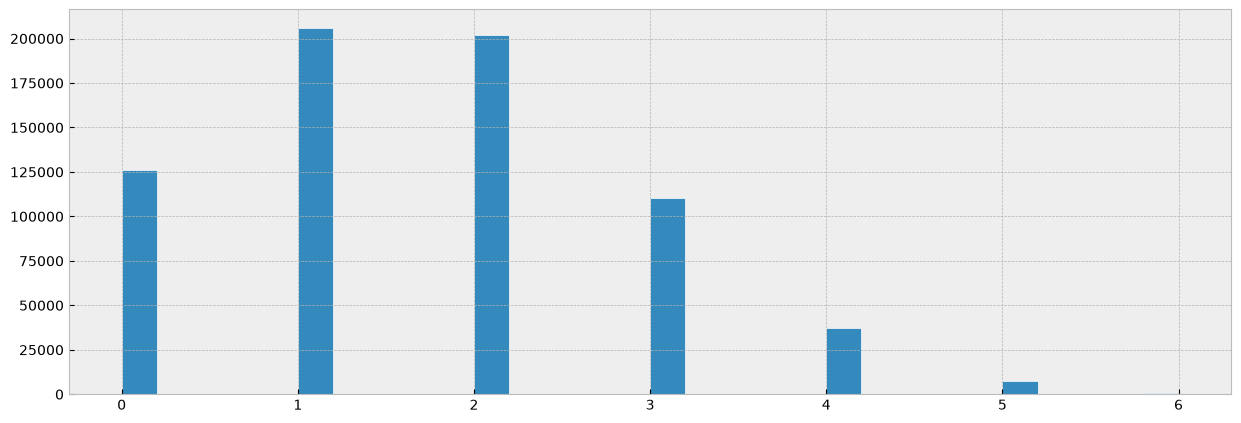

In [13]:
print("健康スコア")
Hist(data=df,column_name="healthy_score",figsize=(15, 5),step=1)

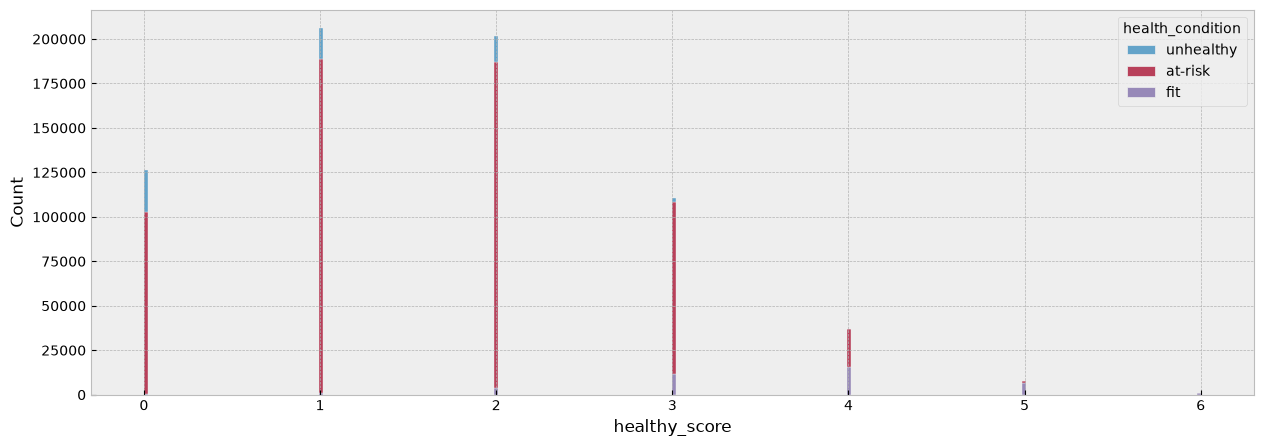

In [14]:
sns_Hist(data=df,x="healthy_score",hue='health_condition',figsize=(15,5),step=1)

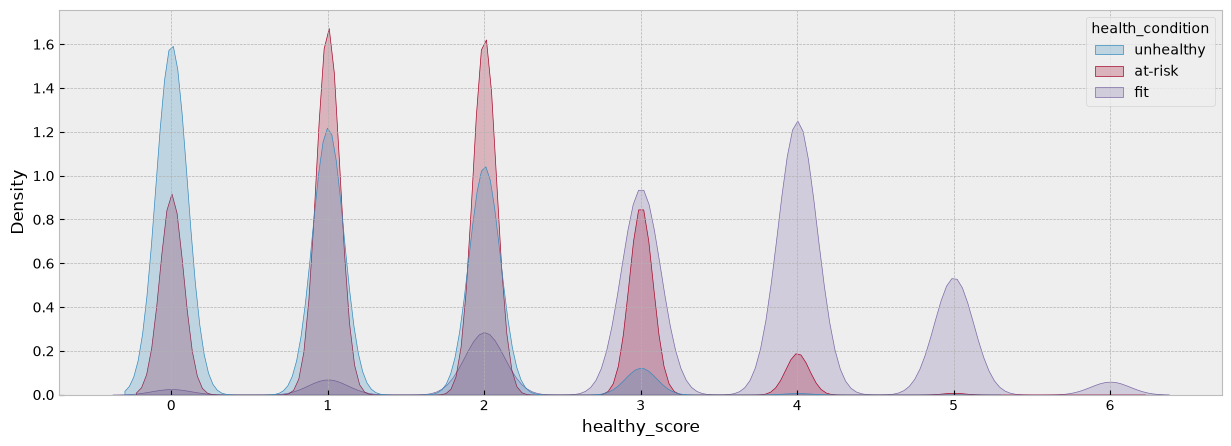

In [15]:
sns_kde(data=df,x="healthy_score",hue='health_condition',figsize=(15, 5),step=1)

# 不健康スコア

不健康スコア


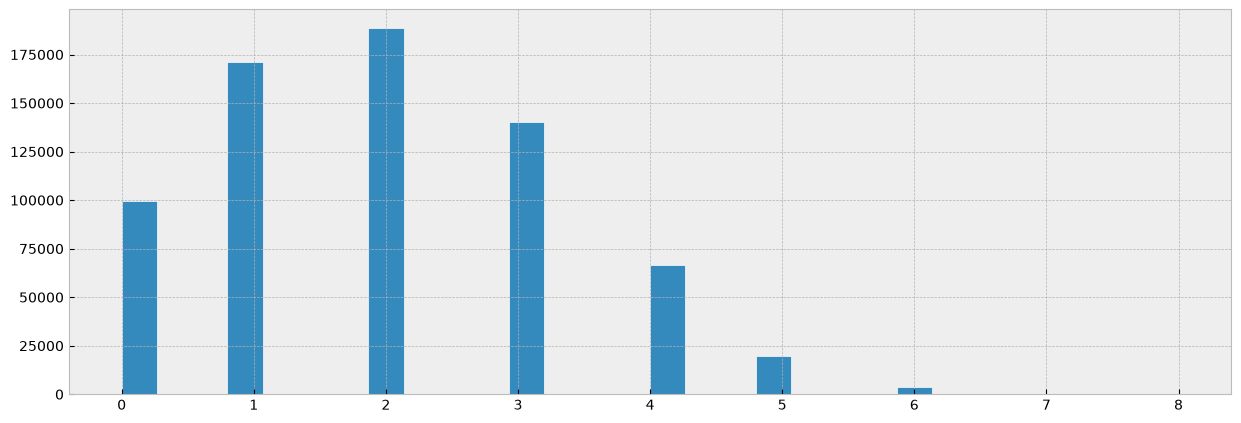

In [16]:
print("不健康スコア")
Hist(data=df,column_name="unhealthy_score",figsize=(15, 5),step=1)

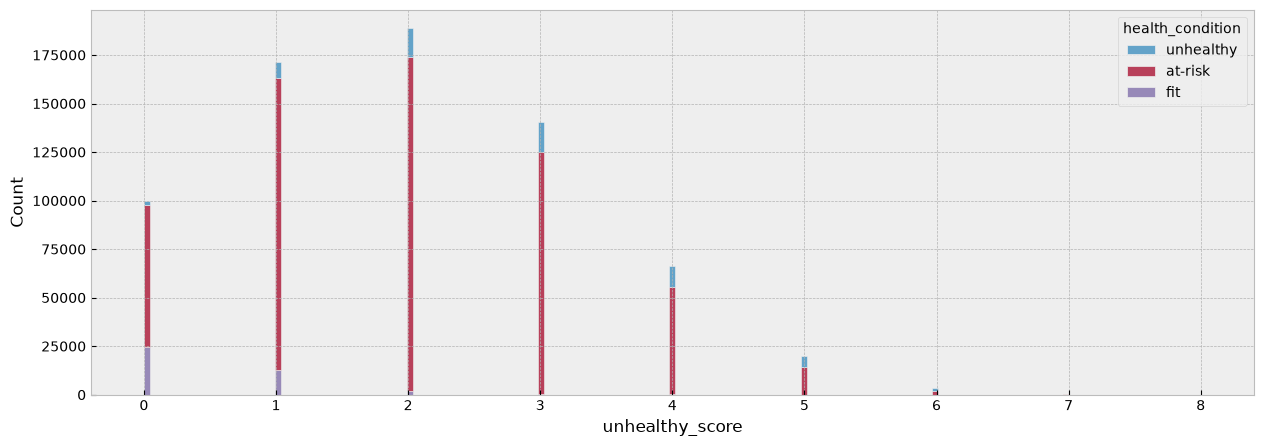

In [17]:
sns_Hist(data=df,x="unhealthy_score",hue='health_condition',figsize=(15,5),step=1)

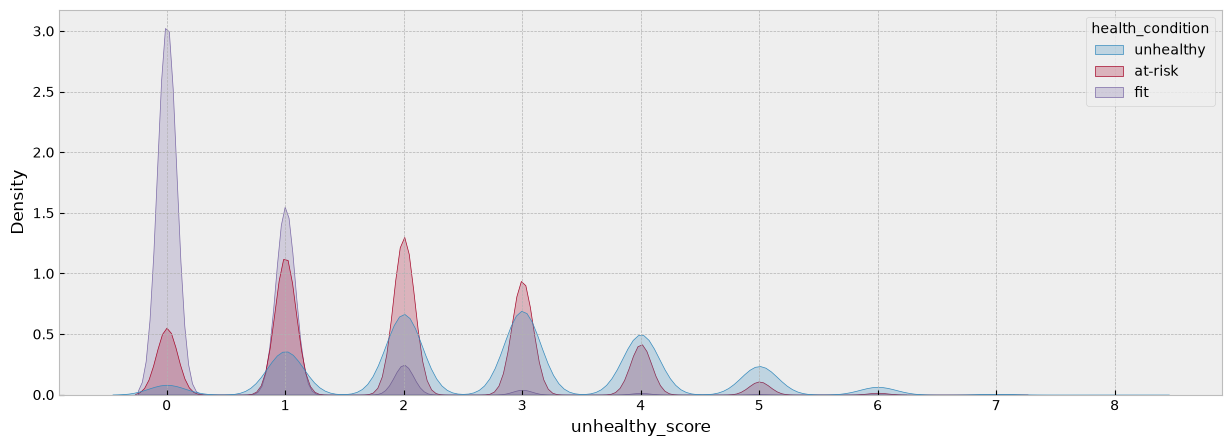

In [18]:
sns_kde(data=df,x="unhealthy_score",hue='health_condition',figsize=(15, 5),step=1)